In [ ]:
pip install pyreaper librosa matplotlib setuptools==81.0.0  praat-parselmouth
 

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install pysptk

In [22]:
paths

[]

In [32]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio
from glob import glob

paths = glob( '/workspace/marcelo/Deepfake/Datasets/wavefake/**/*.wav', recursive=True)

path = paths[10]
y, sr = librosa.load(path)
display(Audio(y, rate=sr))

# Pitch

In [33]:
#pyin
f0_pyin, voiced_flag_pyin, _ = librosa.pyin(y, fmin=50, fmax=400, sr=sr)
times_pyin = librosa.times_like(f0_pyin, sr=sr)

In [37]:
import pyreaper
import numpy as np

# REAPER
y_int16 = (y / np.max(np.abs(y)) * 32767).astype(np.int16)
_, _, times_reaper, f0_reaper, _ = pyreaper.reaper(y_int16, sr)
f0_reaper = f0_reaper.astype(float)
f0_reaper[f0_reaper < 0] = np.nan

Residual symmetry: P:2724.538086  N:1919.151245  MEAN:0.156616
Inverting signal


In [38]:
import numpy as np
import parselmouth
from parselmouth.praat import call

# Praat (parselmouth)
snd = parselmouth.Sound(path)
pitch = call(snd, "To Pitch", 0.0, 50, 400)
n_frames = call(pitch, "Get number of frames")
times_praat = np.array([call(pitch, "Get time from frame number", i+1) for i in range(n_frames)])
f0_praat    = np.array([call(pitch, "Get value in frame", i+1, "Hertz") for i in range(n_frames)])
# f0_praat[f0_praat == 0] = np.nan

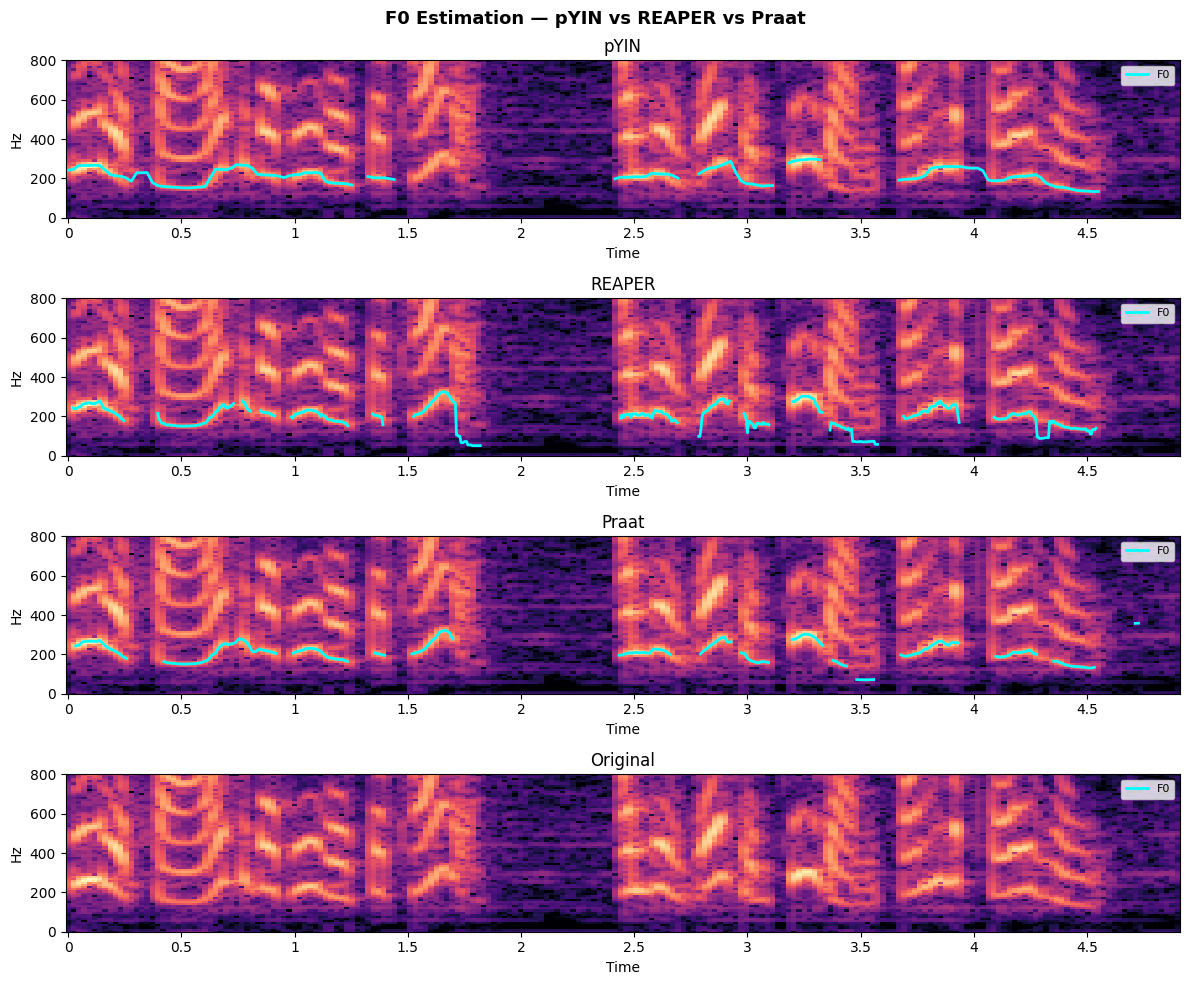

In [39]:
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
fig.suptitle("F0 Estimation — pYIN vs REAPER vs Praat", fontsize=13, fontweight="bold")

configs = [
    ("pYIN",   times_pyin,   f0_pyin,   ),
    ("REAPER", times_reaper, f0_reaper, ),
    ("Praat",  times_praat,  f0_praat,  ),
    ("Original",  np.nan,  np.nan,  ),
]

for ax, (label, times, f0) in zip(axes, configs):
    librosa.display.specshow(D, sr=sr, x_axis="time", y_axis="hz",
                             ax=ax, cmap="magma")
    ax.plot(times, f0, color='cyan', linewidth=2, label="F0")
    ax.set_ylim(0, 800)
    ax.set_title(label)
    ax.set_ylabel("Hz")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

## Jitter

$$
J = \frac{1}{N-1} \sum_{i=1}^{N-1} \left| T_{i+1} - T_i \right|
$$

Essa é a fórmula do **jitter absoluto** (numerador sem normalizar). Os 4 valores que o código imprime são:

**Local** — exatamente essa fórmula, mas dividida pela média dos períodos (normalizada em %):

$$J_{local} = \frac{\frac{1}{N-1} \sum |T_{i+1} - T_i|}{\bar{T}} \times 100$$

**RAP** — mesmo esquema, mas cada termo compara $T_i$ com a média dos 3 vizinhos em vez do anterior direto:

$$J_{RAP} = \frac{\frac{1}{N-2} \sum |T_i - \frac{T_{i-1}+T_i+T_{i+1}}{3}|}{\bar{T}} \times 100$$

**PPQ5** — igual ao RAP mas com janela de 5 períodos:

$$J_{PPQ5} = \frac{\frac{1}{N-4} \sum |T_i - \frac{T_{i-2}+T_{i-1}+T_i+T_{i+1}+T_{i+2}}{5}|}{\bar{T}} \times 100$$

**DDP** — diferença das diferenças (segunda derivada discreta dos períodos), normalizada:

$$J_{DDP} = \frac{\frac{1}{N-2} \sum |(T_{i+1}-T_i) - (T_i - T_{i-1})|}{\bar{T}} \times 100$$

DDP é equivalente a 3× RAP no PRAAT — mede a aceleração da variação de período em vez da variação direta.

In [11]:
# pYIN — jitter aproximado via pitch marks sintéticos
voiced_f0_pyin = f0_pyin[voiced_flag_pyin & (f0_pyin > 0)]

# Converter F0 → períodos → acumular em marcos sintéticos
T_pyin  = 1.0 / voiced_f0_pyin
pm_pyin = np.cumsum(T_pyin)              # marcos sintéticos em segundos

jitter_local_pyin = np.mean(np.abs(np.diff(T_pyin))) / np.mean(T_pyin) * 100
jitter_rap_pyin   = np.mean([abs(T_pyin[i] - np.mean(T_pyin[i-1:i+2])) for i in range(1, len(T_pyin)-1)]) / np.mean(T_pyin) * 100
jitter_ppq5_pyin  = np.mean([abs(T_pyin[i] - np.mean(T_pyin[i-2:i+3])) for i in range(2, len(T_pyin)-2)]) / np.mean(T_pyin) * 100
jitter_ddp_pyin   = np.mean(np.abs(np.diff(np.abs(np.diff(T_pyin))))) / np.mean(T_pyin) * 100

print(f"Local : {jitter_local_pyin:.4f}%")
print(f"RAP   : {jitter_rap_pyin:.4f}%")
print(f"PPQ5  : {jitter_ppq5_pyin:.4f}%")
print(f"DDP   : {jitter_ddp_pyin:.4f}%")

Local : 4.1310%
RAP   : 1.8731%
PPQ5  : 3.0432%
DDP   : 4.5341%


In [40]:
# ── REAPER: jitter aproximado via F0 frame-a-frame ──────────────────────────
_, _, times_reaper, f0_reaper, _ = pyreaper.reaper(y_int16, sr)
f0_reaper = f0_reaper.astype(float)
f0_reaper[f0_reaper < 0] = np.nan

T_reaper = 1.0 / f0_reaper[~np.isnan(f0_reaper)]

jitter_local_reaper = np.mean(np.abs(np.diff(T_reaper))) / np.mean(T_reaper) * 100
jitter_rap_reaper   = np.mean([abs(T_reaper[i] - np.mean(T_reaper[i-1:i+2])) for i in range(1, len(T_reaper)-1)]) / np.mean(T_reaper) * 100
jitter_ppq5_reaper  = np.mean([abs(T_reaper[i] - np.mean(T_reaper[i-2:i+3])) for i in range(2, len(T_reaper)-2)]) / np.mean(T_reaper) * 100
jitter_ddp_reaper   = np.mean(np.abs(np.diff(np.abs(np.diff(T_reaper))))) / np.mean(T_reaper) * 100

print(f"Local : {jitter_local_reaper:.4f}%")
print(f"RAP   : {jitter_rap_reaper:.4f}%")
print(f"PPQ5  : {jitter_ppq5_reaper:.4f}%")
print(f"DDP   : {jitter_ddp_reaper:.4f}%")

Residual symmetry: P:2724.538086  N:1919.151245  MEAN:0.156616
Inverting signal
Local : 4.3789%
RAP   : 2.5135%
PPQ5  : 4.0217%
DDP   : 6.7124%


In [42]:
# ── PRAAT: jitter per-cycle via parselmouth ──────────────────────────────────
import parselmouth
from parselmouth.praat import call

snd = parselmouth.Sound(path)   # ou: parselmouth.Sound(y, sr)
point_process = call(snd, "To PointProcess (periodic, cc)", 75, 500)

# parâmetros: tmin, tmax, period_floor, period_ceiling, max_period_factor
jitter_local_praat = call(point_process, "Get jitter (local)",          0, 0, 0.0001, 0.02, 1.3) * 100
jitter_rap_praat   = call(point_process, "Get jitter (rap)",            0, 0, 0.0001, 0.02, 1.3) * 100
jitter_ppq5_praat  = call(point_process, "Get jitter (ppq5)",           0, 0, 0.0001, 0.02, 1.3) * 100
jitter_ddp_praat   = call(point_process, "Get jitter (ddp)",            0, 0, 0.0001, 0.02, 1.3) * 100

print(f"Local : {jitter_local_praat:.4f}%")
print(f"RAP   : {jitter_rap_praat:.4f}%")
print(f"PPQ5  : {jitter_ppq5_praat:.4f}%")
print(f"DDP   : {jitter_ddp_praat:.4f}%")

Local : 2.5931%
RAP   : 1.1161%
PPQ5  : 1.2486%
DDP   : 3.3482%


## Shimmer

$$
S = \frac{1}{N-1} \sum_{i=1}^{N-1} \left| A_{i+1} - A_i \right|
$$

As fórmulas do shimmer são análogas ao jitter, mas operando em amplitudes $A_i$ em vez de períodos $T_i$:

**Local (%)**

$$S_{local} = \frac{\frac{1}{N-1} \sum_{i=1}^{N-1} |A_{i+1} - A_i|}{\bar{A}} \times 100$$

**Local (dB)**

$$S_{dB} = \frac{1}{N-1} \sum_{i=1}^{N-1} \left| 20 \cdot \log_{10} \frac{A_{i+1}}{A_i} \right|$$

**APQ3** *(Amplitude Perturbation Quotient, janela 3)*

$$S_{APQ3} = \frac{\frac{1}{N-2} \sum_{i=2}^{N-1} \left| A_i - \frac{A_{i-1}+A_i+A_{i+1}}{3} \right|}{\bar{A}} \times 100$$

**APQ5** *(janela 5)*

$$S_{APQ5} = \frac{\frac{1}{N-4} \sum_{i=3}^{N-2} \left| A_i - \frac{A_{i-2}+A_{i-1}+A_i+A_{i+1}+A_{i+2}}{5} \right|}{\bar{A}} \times 100$$

**DDA** *(análogo ao DDP — diferença das diferenças, equivale a 3× APQ3)*

$$S_{DDA} = \frac{\frac{1}{N-2} \sum_{i=2}^{N-1} |(A_{i+1}-A_i) - (A_i-A_{i-1})|}{\bar{A}} \times 100$$

A diferença chave em relação ao jitter: $A_i$ é a amplitude de pico do ciclo glotal $i$, que o REAPER e o pYIN **não fornecem diretamente** — por isso shimmer precisa do parselmouth/PRAAT para extração correta.

In [47]:
# ── pYIN: shimmer aproximado via amplitude RMS por frame ─────────────────────
hop_length_pyin = 512

rms_pyin = librosa.feature.rms(y=y, frame_length=2048, hop_length=hop_length_pyin)[0]

n_frames_pyin    = min(len(voiced_flag_pyin), len(rms_pyin))
voiced_mask_pyin = voiced_flag_pyin[:n_frames_pyin] & (f0_pyin[:n_frames_pyin] > 0)
A_pyin           = rms_pyin[:n_frames_pyin][voiced_mask_pyin]

shimmer_local_pyin = np.mean(np.abs(np.diff(A_pyin))) / np.mean(A_pyin) * 100
shimmer_dB_pyin    = np.mean(np.abs(20 * np.log10(A_pyin[1:] / A_pyin[:-1])))
shimmer_apq3_pyin  = np.mean([abs(A_pyin[i] - np.mean(A_pyin[i-1:i+2])) for i in range(1, len(A_pyin)-1)]) / np.mean(A_pyin) * 100
shimmer_apq5_pyin  = np.mean([abs(A_pyin[i] - np.mean(A_pyin[i-2:i+3])) for i in range(2, len(A_pyin)-2)]) / np.mean(A_pyin) * 100
shimmer_dda_pyin   = np.mean(np.abs(np.diff(np.abs(np.diff(A_pyin))))) / np.mean(A_pyin) * 100

print(f"Local : {shimmer_local_pyin:.4f}%")
print(f"dB    : {shimmer_dB_pyin:.4f} dB")
print(f"APQ3  : {shimmer_apq3_pyin:.4f}%")
print(f"APQ5  : {shimmer_apq5_pyin:.4f}%")
print(f"DDA   : {shimmer_dda_pyin:.4f}%")

Local : 18.1713%
dB    : 2.2443 dB
APQ3  : 5.2901%
APQ5  : 11.6574%
DDA   : 12.8384%


In [46]:
# ── REAPER: shimmer aproximado via amplitude RMS por frame ───────────────────
frame_len = int(0.025 * sr)
hop_len   = int(0.005 * sr)

rms_frames = np.array([
    np.sqrt(np.mean(y[i:i+frame_len]**2))
    for i in range(0, len(y) - frame_len, hop_len)
])

n_frames           = min(len(f0_reaper), len(rms_frames))
voiced_mask_reaper = ~np.isnan(f0_reaper[:n_frames])
A_reaper           = rms_frames[:n_frames][voiced_mask_reaper]

shimmer_local_reaper = np.mean(np.abs(np.diff(A_reaper))) / np.mean(A_reaper) * 100
shimmer_dB_reaper    = np.mean(np.abs(20 * np.log10(A_reaper[1:] / A_reaper[:-1])))
shimmer_apq3_reaper  = np.mean([abs(A_reaper[i] - np.mean(A_reaper[i-1:i+2])) for i in range(1, len(A_reaper)-1)]) / np.mean(A_reaper) * 100
shimmer_apq5_reaper  = np.mean([abs(A_reaper[i] - np.mean(A_reaper[i-2:i+3])) for i in range(2, len(A_reaper)-2)]) / np.mean(A_reaper) * 100
shimmer_dda_reaper   = np.mean(np.abs(np.diff(np.abs(np.diff(A_reaper))))) / np.mean(A_reaper) * 100

print(f"Local : {shimmer_local_reaper:.4f}%")
print(f"dB    : {shimmer_dB_reaper:.4f} dB")
print(f"APQ3  : {shimmer_apq3_reaper:.4f}%")
print(f"APQ5  : {shimmer_apq5_reaper:.4f}%")
print(f"DDA   : {shimmer_dda_reaper:.4f}%")

Local : 8.5877%
dB    : 1.0056 dB
APQ3  : 2.4351%
APQ5  : 4.5075%
DDA   : 5.9347%


In [45]:
# ── PRAAT: shimmer per-cycle via parselmouth ─────────────────────────────────
import parselmouth
from parselmouth.praat import call

snd          = parselmouth.Sound(y.astype(float) / 32768.0, sr)  # se y for int16
point_process = call(snd, "To PointProcess (periodic, cc)", 75, 500)

# parâmetros: tmin, tmax, period_floor, period_ceiling, max_period_factor, max_amp_factor
shimmer_local  = call([snd, point_process], "Get shimmer (local)",    0, 0, 0.0001, 0.02, 1.3, 1.6) * 100
shimmer_dB     = call([snd, point_process], "Get shimmer (local_dB)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
shimmer_apq3   = call([snd, point_process], "Get shimmer (apq3)",     0, 0, 0.0001, 0.02, 1.3, 1.6) * 100
shimmer_apq5   = call([snd, point_process], "Get shimmer (apq5)",     0, 0, 0.0001, 0.02, 1.3, 1.6) * 100
shimmer_dda    = call([snd, point_process], "Get shimmer (dda)",      0, 0, 0.0001, 0.02, 1.3, 1.6) * 100

print(f"Local : {shimmer_local:.4f}%")
print(f"dB    : {shimmer_dB:.4f} dB")
print(f"APQ3  : {shimmer_apq3:.4f}%")
print(f"APQ5  : {shimmer_apq5:.4f}%")
print(f"DDA   : {shimmer_dda:.4f}%")

Local : 8.5852%
dB    : 0.8847 dB
APQ3  : 3.2548%
APQ5  : 4.3229%
DDA   : 9.7645%


## HNR


$$HNR = 10 \cdot \log_{10} \left( \frac{P_{harmonic}}{P_{noise}} \right) = 10 \cdot \log_{10} \left( \frac{r(\tau_0)}{1 - r(\tau_0)} \right)$$

onde $r(\tau_0)$ é o pico normalizado da autocorrelação no lag $\tau_0 = 1/F_0$ (período fundamental). Quanto mais periódico o sinal, mais alto o pico de autocorrelação e maior o HNR.

Valores de referência: vozes saudáveis tipicamente acima de **20 dB**, vozes patológicas abaixo de **15 dB**.

In [51]:
# ── librosa: HNR aproximado via autocorrelação ───────────────────────────────
hop_length = 512
frame_length = 2048

f0_lib, voiced_flag_lib, _ = librosa.pyin(
    y, fmin=50, fmax=400, sr=sr, hop_length=hop_length
)

hnr_frames = []
for i, (f0_val, voiced) in enumerate(zip(f0_lib, voiced_flag_lib)):
    if not voiced or f0_val <= 0:
        continue

    start = i * hop_length
    frame = y[start:start + frame_length]
    if len(frame) < frame_length:
        continue

    # autocorrelação normalizada
    r = np.correlate(frame, frame, mode='full')
    r = r[len(r)//2:]
    r /= r[0]

    # lag correspondente a F0
    lag = int(round(sr / f0_val))
    if lag <= 0 or lag >= len(r):
        continue

    r0 = np.clip(r[lag], 1e-10, 1 - 1e-10)
    hnr_frames.append(10 * np.log10(r0 / (1 - r0)))

hnr_librosa = np.mean(hnr_frames)
print(f"HNR (librosa): {hnr_librosa:.4f} dB")

HNR (librosa): -14.7337 dB


In [49]:
# ── REAPER: HNR via coeficiente de correlação nativo ────────────────────────
_, _, times_reaper, f0_reaper, corr_reaper = pyreaper.reaper(y_int16, sr)

f0_reaper   = f0_reaper.astype(float)
corr_reaper = corr_reaper.astype(float)

# filtrar frames vozeados (f0 > 0 e correlação válida)
voiced_mask_reaper = (f0_reaper > 0) & (corr_reaper > 0) & (corr_reaper < 1)

r = corr_reaper[voiced_mask_reaper]
r = np.clip(r, 1e-10, 1 - 1e-10)

hnr_reaper = np.mean(10 * np.log10(r / (1 - r)))
print(f"HNR (REAPER): {hnr_reaper:.4f} dB")

Residual symmetry: P:2724.538086  N:1919.151245  MEAN:0.156616
Inverting signal
HNR (REAPER): 9.6366 dB


In [50]:
# ── PRAAT: HNR via harmonicidade (autocorrelação corrigida) ──────────────────
import parselmouth
from parselmouth.praat import call

snd = parselmouth.Sound(y.astype(float) / 32768.0, sr)  # se y for int16

# cc = cross-correlation (mais preciso que ac para vozes reais)
harmonicity = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)

hnr_praat = call(harmonicity, "Get mean", 0, 0)
print(f"HNR (PRAAT): {hnr_praat:.4f} dB")

HNR (PRAAT): 9.9636 dB


# VAD

In [52]:
pip install silero-vad

  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 10.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.6/530.6 MB 10.2 MB/s  0:00:48m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 11.3 MB/s  0:00:32m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 11.4 MB/s  0:00:14m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 10.8 MB/s  0:00:18m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 11.5 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.2/188.2 MB 10.9 MB/s  0:00:17m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 10.1 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 11.5 MB/s  0:00:36m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 11.2 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from silero_vad import load_silero_vad, read_audio, get_speech_timestamps
model = load_silero_vad()


In [80]:
import torch
import librosa

# carregar com librosa em vez do torchaudio
y_vad, sr_vad = librosa.load(path, sr=16000, mono=True)  # silero exige 16kHz

# converter para tensor float32 no formato esperado pelo silero
wav = torch.from_numpy(y_vad).unsqueeze(0)  # shape: (1, N)

speech_timestamps = get_speech_timestamps(
    wav,

    
    model,
    sampling_rate=sr_vad,
    return_seconds=True,
     threshold=0.8, 
)
print(speech_timestamps)

[{'start': 0.0, 'end': 2.1}, {'start': 2.4, 'end': 4.9}]


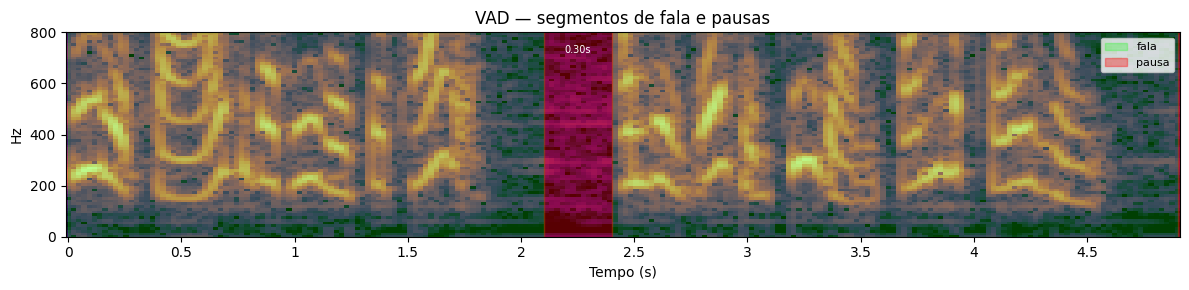

In [77]:
# ── VAD: visualizar pausas detectadas ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3))

# espectrograma de fundo
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
librosa.display.specshow(D, sr=sr, x_axis="time", y_axis="hz",
                         ax=ax, cmap="magma")

# duração total do áudio
total_duration = len(y) / sr

# regiões de fala (verde) e pausa (vermelho)
speech_intervals = [(s["start"], s["end"]) for s in speech_timestamps]

# pintar pausas: gaps entre segmentos de fala
pause_intervals = []
prev_end = 0.0
for start, end in speech_intervals:
    if start > prev_end:
        pause_intervals.append((prev_end, start))
    prev_end = end
if prev_end < total_duration:
    pause_intervals.append((prev_end, total_duration))

for start, end in speech_intervals:
    ax.axvspan(start, end, ymin=0, ymax=1, alpha=0.25, color="lime",  label="fala")
for start, end in pause_intervals:
    ax.axvspan(start, end, ymin=0, ymax=1, alpha=0.35, color="red",   label="pausa")

# remover labels duplicados na legenda
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=8)

ax.set_ylim(0, 800)
ax.set_title("VAD — segmentos de fala e pausas")
ax.set_ylabel("Hz")
ax.set_xlabel("Tempo (s)")

# anotar duração de cada pausa
for start, end in pause_intervals:
    duration = end - start
    if duration > 0.05:   # ignorar pausas menores que 50 ms
        ax.text((start + end) / 2, 750, f"{duration:.2f}s",
                ha="center", va="top", fontsize=7, color="white")

plt.tight_layout()
plt.show()

Residual symmetry: P:2724.538086  N:1919.151245  MEAN:0.156616
Inverting signal


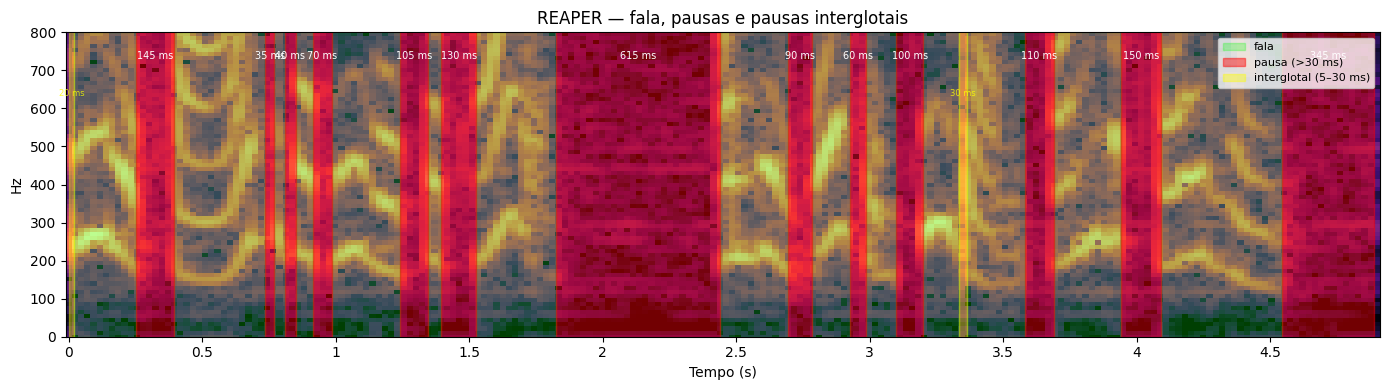

Fala         (voiced) : 14 segmentos — duração total: 2845.0 ms
Pausas       (>30 ms) : 13 — duração total: 1995.0 ms
Interglotais (5–30ms) : 2 — duração total: 50.0 ms


In [61]:
# ── REAPER: pausas e pausas interglotais ─────────────────────────────────────
_, _, times_reaper, f0_reaper, corr_reaper = pyreaper.reaper(y_int16, sr)

f0_reaper = f0_reaper.astype(float)
f0_reaper[f0_reaper < 0] = np.nan

FRAME_PERIOD  = 0.005
MIN_PAUSE     = 0.030
MIN_INTERGLOT = 0.005

voiced   = ~np.isnan(f0_reaper)
unvoiced =  np.isnan(f0_reaper)

def get_runs(mask, times, frame_period):
    runs = []
    in_run = False
    for i, v in enumerate(mask):
        if v and not in_run:
            start = times[i]
            in_run = True
        elif not v and in_run:
            runs.append((start, times[i - 1] + frame_period))
            in_run = False
    if in_run:
        runs.append((start, times[-1] + frame_period))
    return runs

voiced_runs   = get_runs(voiced,   times_reaper, FRAME_PERIOD)
unvoiced_runs = get_runs(unvoiced, times_reaper, FRAME_PERIOD)

pausas       = [(s, e) for s, e in unvoiced_runs if (e - s) >= MIN_PAUSE]
interglotais = [(s, e) for s, e in unvoiced_runs if MIN_INTERGLOT <= (e - s) < MIN_PAUSE]

# ── plot ──────────────────────────────────────────────────────────────────────
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

fig, ax = plt.subplots(figsize=(14, 4))
librosa.display.specshow(D, sr=sr, x_axis="time", y_axis="hz",
                         ax=ax, cmap="magma")

for s, e in voiced_runs:
    ax.axvspan(s, e, alpha=0.25, color="lime",   label="fala")
for s, e in pausas:
    ax.axvspan(s, e, alpha=0.45, color="red",    label="pausa (>30 ms)")
for s, e in interglotais:
    ax.axvspan(s, e, alpha=0.40, color="yellow", label="interglotal (5–30 ms)")

# anotar durações
for s, e in pausas:
    ax.text((s + e) / 2, 750, f"{(e-s)*1000:.0f} ms",
            ha="center", va="top", fontsize=7, color="white")
for s, e in interglotais:
    ax.text((s + e) / 2, 650, f"{(e-s)*1000:.0f} ms",
            ha="center", va="top", fontsize=6, color="yellow", alpha=0.8)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=8)

ax.set_ylim(0, 800)
ax.set_title("REAPER — fala, pausas e pausas interglotais")
ax.set_ylabel("Hz")
ax.set_xlabel("Tempo (s)")

plt.tight_layout()
plt.show()

print(f"Fala         (voiced) : {len(voiced_runs)} segmentos — duração total: {sum(e-s for s,e in voiced_runs)*1000:.1f} ms")
print(f"Pausas       (>30 ms) : {len(pausas)} — duração total: {sum(e-s for s,e in pausas)*1000:.1f} ms")
print(f"Interglotais (5–30ms) : {len(interglotais)} — duração total: {sum(e-s for s,e in interglotais)*1000:.1f} ms")

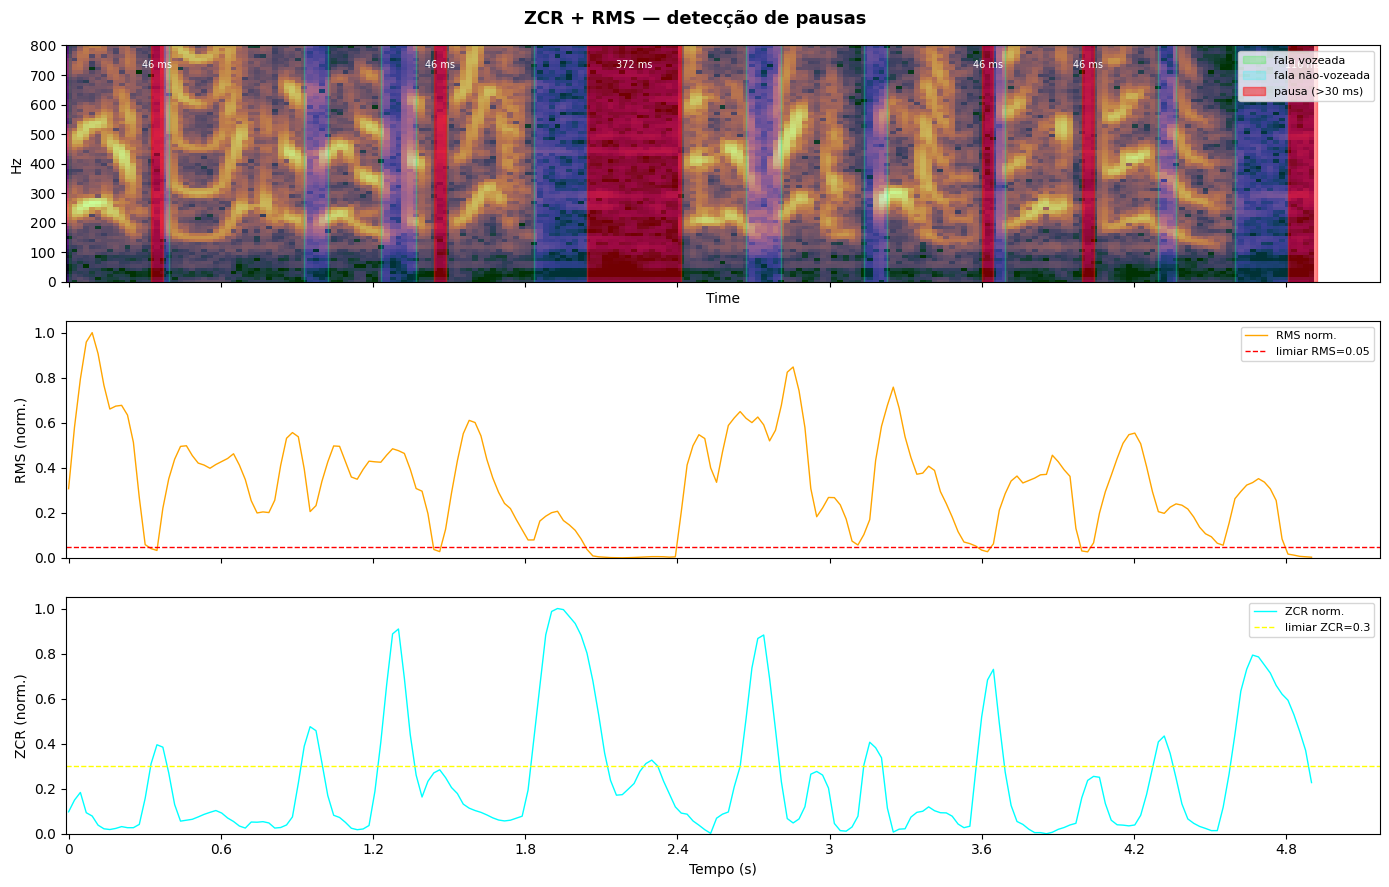

Fala vozeada     : 11 segmentos — 3227.6 ms
Fala não-vozeada : 9 segmentos — 1021.7 ms
Pausas  (>30 ms) : 6 — 673.4 ms
Interglotais     : 0 — 0.0 ms


In [81]:
# ── ZCR + RMS: detecção de pausas via heurística ─────────────────────────────
frame_length = 2048
hop_length   = 512

rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
zcr = librosa.feature.zero_crossing_rate(y, frame_length=frame_length, hop_length=hop_length)[0]
times_frames = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)

# normalizar para [0, 1]
rms_norm = (rms - rms.min()) / (rms.max() - rms.min() + 1e-10)
zcr_norm = (zcr - zcr.min()) / (zcr.max() - zcr.min() + 1e-10)

# limiares (ajustáveis)
RMS_THRESH = 0.05   # abaixo = silêncio
ZCR_THRESH = 0.30   # fala vozeada tem ZCR baixo; fricativas têm ZCR alto

# heurística combinada:
# pausa          = RMS baixo
# interglotal    = RMS baixo E ZCR alto (fricativa/plosiva/aspiração)
# fala vozeada   = RMS alto  E ZCR baixo
# fala não-voz.  = RMS alto  E ZCR alto (fricativas sonoras)
is_silent   = rms_norm < RMS_THRESH
is_voiced   = (rms_norm >= RMS_THRESH) & (zcr_norm < ZCR_THRESH)
is_unvoiced = (rms_norm >= RMS_THRESH) & (zcr_norm >= ZCR_THRESH)

def get_runs_array(mask, times, hop_length, sr):
    runs = []
    in_run = False
    frame_dur = hop_length / sr
    for i, v in enumerate(mask):
        if v and not in_run:
            start = times[i]
            in_run = True
        elif not v and in_run:
            runs.append((start, times[i - 1] + frame_dur))
            in_run = False
    if in_run:
        runs.append((start, times[-1] + hop_length / sr))
    return runs

MIN_PAUSE     = 0.030
MIN_INTERGLOT = 0.005

silent_runs   = get_runs_array(is_silent,   times_frames, hop_length, sr)
voiced_runs   = get_runs_array(is_voiced,   times_frames, hop_length, sr)
unvoiced_runs = get_runs_array(is_unvoiced, times_frames, hop_length, sr)

pausas       = [(s, e) for s, e in silent_runs  if (e - s) >= MIN_PAUSE]
interglotais = [(s, e) for s, e in silent_runs  if MIN_INTERGLOT <= (e - s) < MIN_PAUSE]

# ── plot ──────────────────────────────────────────────────────────────────────
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle("ZCR + RMS — detecção de pausas", fontsize=13, fontweight="bold")

# ── subplot 1: espectrograma + regiões ───────────────────────────────────────
ax = axes[0]
librosa.display.specshow(D, sr=sr, x_axis="time", y_axis="hz", ax=ax, cmap="magma")

for s, e in voiced_runs:
    ax.axvspan(s, e, alpha=0.20, color="lime",   label="fala vozeada")
for s, e in unvoiced_runs:
    ax.axvspan(s, e, alpha=0.20, color="cyan",   label="fala não-vozeada")
for s, e in pausas:
    ax.axvspan(s, e, alpha=0.45, color="red",    label="pausa (>30 ms)")
for s, e in interglotais:
    ax.axvspan(s, e, alpha=0.40, color="yellow", label="interglotal (5–30 ms)")

for s, e in pausas:
    ax.text((s + e) / 2, 750, f"{(e-s)*1000:.0f} ms",
            ha="center", va="top", fontsize=7, color="white")

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=8)
ax.set_ylim(0, 800)
ax.set_ylabel("Hz")

# ── subplot 2: RMS ────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(times_frames, rms_norm, color="orange", linewidth=1, label="RMS norm.")
ax.axhline(RMS_THRESH, color="red", linewidth=1, linestyle="--", label=f"limiar RMS={RMS_THRESH}")
ax.set_ylabel("RMS (norm.)")
ax.legend(loc="upper right", fontsize=8)
ax.set_ylim(0, 1.05)

# ── subplot 3: ZCR ────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(times_frames, zcr_norm, color="cyan", linewidth=1, label="ZCR norm.")
ax.axhline(ZCR_THRESH, color="yellow", linewidth=1, linestyle="--", label=f"limiar ZCR={ZCR_THRESH}")
ax.set_ylabel("ZCR (norm.)")
ax.set_xlabel("Tempo (s)")
ax.legend(loc="upper right", fontsize=8)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# ── resumo ────────────────────────────────────────────────────────────────────
print(f"Fala vozeada     : {len(voiced_runs)} segmentos — {sum(e-s for s,e in voiced_runs)*1000:.1f} ms")
print(f"Fala não-vozeada : {len(unvoiced_runs)} segmentos — {sum(e-s for s,e in unvoiced_runs)*1000:.1f} ms")
print(f"Pausas  (>30 ms) : {len(pausas)} — {sum(e-s for s,e in pausas)*1000:.1f} ms")
print(f"Interglotais     : {len(interglotais)} — {sum(e-s for s,e in interglotais)*1000:.1f} ms")

# Fingerprint

In [82]:
fake = "/workspace/marcelo/Deepfake/Datasets/CodecFake/data/wavs/audiodec_24k_320d+p310_350.wav"
real = "/workspace/marcelo/Deepfake/Datasets/VCTK-Corpus/VCTK-Corpus/wav48/p310/p310_350.wav"


In [100]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
 
# ── carregamento ──────────────────────────────────────────────────────────────
y_fake, sr_fake = librosa.load(fake, sr=None, mono=True)
y_real, sr_real = librosa.load(real, sr=None, mono=True)
 
if sr_fake != sr_real:
    y_fake = librosa.resample(y_fake, orig_sr=sr_fake, target_sr=sr_real)
sr = sr_real
 
# ── alinhamento por comprimento ───────────────────────────────────────────────
min_len   = min(len(y_fake), len(y_real))
y_fake    = y_fake[:min_len]
y_real    = y_real[:min_len]
times_wav = np.linspace(0, min_len / sr, min_len)
 
# ── normalização de amplitude (isola diferenças de conteúdo do ganho) ─────────
y_real = y_real / (np.max(np.abs(y_real)) + 1e-9)
y_fake = y_fake / (np.max(np.abs(y_fake)) + 1e-9)
 
# ── resíduo ───────────────────────────────────────────────────────────────────
residuo_wav = y_real - y_fake
 
# ── métricas normalizadas ─────────────────────────────────────────────────────
rms_real = np.sqrt(np.mean(y_real**2)) + 1e-9
mae      = np.mean(np.abs(residuo_wav))
rms_res  = np.sqrt(np.mean(residuo_wav**2))
snr_db   = 20 * np.log10(rms_real / (rms_res + 1e-9))
max_err  = np.max(np.abs(residuo_wav))
bias     = np.mean(residuo_wav)
 
print(f"sr           : {sr} Hz  |  duração comparada: {min_len/sr:.3f} s")
print(f"MAE          : {mae:.6f}")
print(f"RMS resíduo  : {rms_res:.6f}")
print(f"SNR          : {snr_db:.2f} dB  (quanto maior, mais fiel o fake)")
print(f"Max erro     : {max_err:.6f}")
print(f"Viés médio   : {bias:+.6f}  {'(real maior)' if bias>0 else '(fake maior)'}")

sr           : 48000 Hz  |  duração comparada: 2.048 s
MAE          : 0.072757
RMS resíduo  : 0.149392
SNR          : -3.16 dB  (quanto maior, mais fiel o fake)
Max erro     : 1.633670
Viés médio   : +0.017544  (real maior)


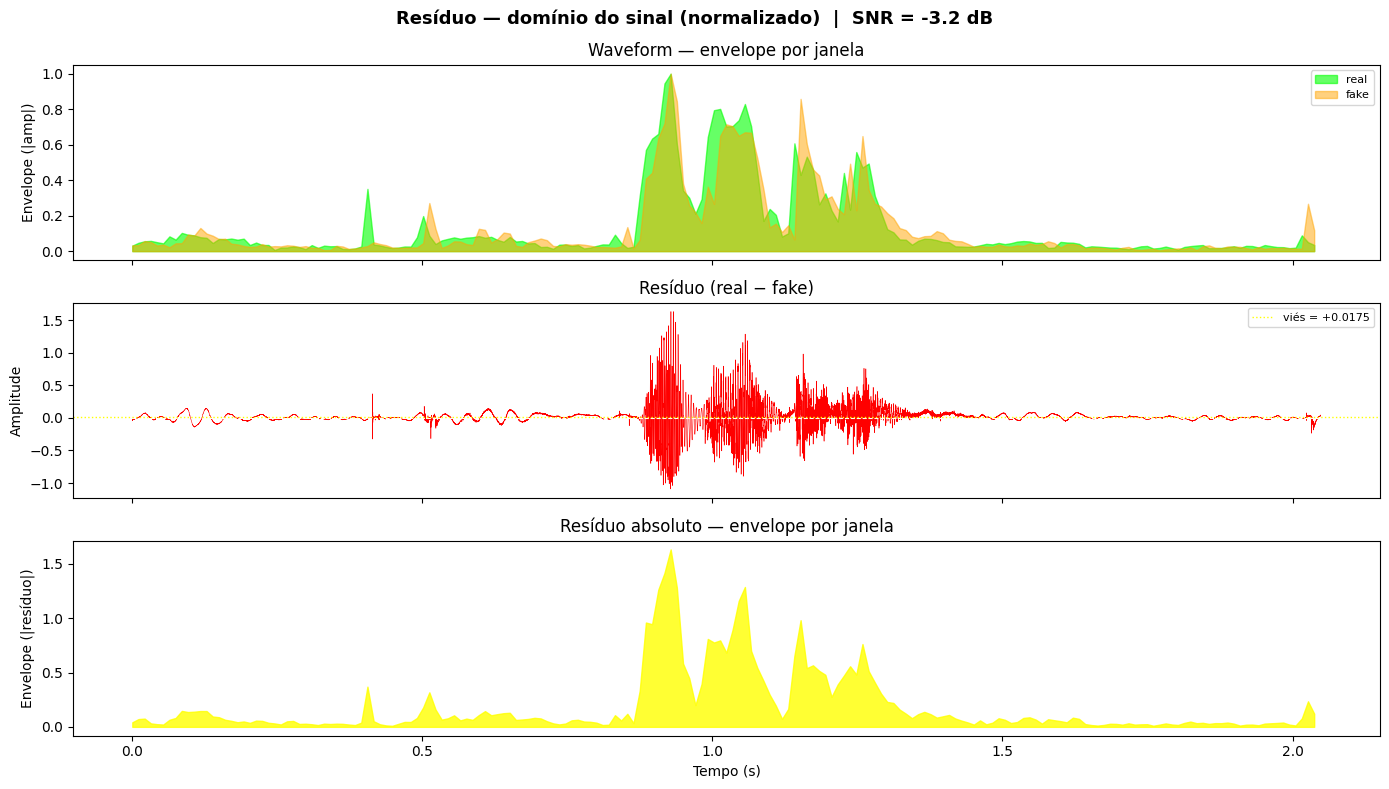

In [101]:
# ── envelope por janela (legível para qualquer duração) ───────────────────────
def envelope(sig, frame=512):
    n = len(sig) // frame * frame
    return np.max(np.abs(sig[:n].reshape(-1, frame)), axis=1)
 
def env_times(sig, sr, frame=512):
    n_frames = len(sig) // frame
    return np.arange(n_frames) * frame / sr
 
frame   = 512
t_env   = env_times(y_real, sr, frame)
env_r   = envelope(y_real,      frame)
env_f   = envelope(y_fake,      frame)
env_abs = envelope(np.abs(residuo_wav), frame)
 
# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle(
    f"Resíduo — domínio do sinal (normalizado)  |  SNR = {snr_db:.1f} dB",
    fontsize=13, fontweight="bold"
)
 
# painel 1: envelope das waveforms
axes[0].fill_between(t_env, env_r, alpha=0.6, color="lime",   label="real")
axes[0].fill_between(t_env, env_f, alpha=0.5, color="orange", label="fake")
axes[0].set_ylabel("Envelope (|amp|)")
axes[0].set_title("Waveform — envelope por janela")
axes[0].legend(loc="upper right", fontsize=8)
 
# painel 2: resíduo com linha de viés
axes[1].plot(times_wav, residuo_wav, color="red", linewidth=0.4)
axes[1].axhline(0,    color="white",  linewidth=0.8, linestyle="--")
axes[1].axhline(bias, color="yellow", linewidth=1.0, linestyle=":",
                label=f"viés = {bias:+.4f}")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Resíduo (real − fake)")
axes[1].legend(loc="upper right", fontsize=8)
 
# painel 3: envelope do resíduo absoluto
axes[2].fill_between(t_env, env_abs, color="yellow", alpha=0.8)
axes[2].set_ylabel("Envelope (|resíduo|)")
axes[2].set_title("Resíduo absoluto — envelope por janela")
axes[2].set_xlabel("Tempo (s)")
 
plt.tight_layout()
plt.show()

Cobertura da comparação: 99.9% da duração total

sr real (original) : 48000 Hz  |  duração: 2.048 s
sr fake (original) : 24000 Hz  |  duração: 2.050 s
sr comum usado      : 22050 Hz

MAE espectral  : 3.2997 dB
RMS espectral  : 5.0526 dB
Max espectral  : 28.0918 dB
Viés médio     : -1.8938 dB  (fake mais energético)


/tmp/ipykernel_33292/3181733906.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


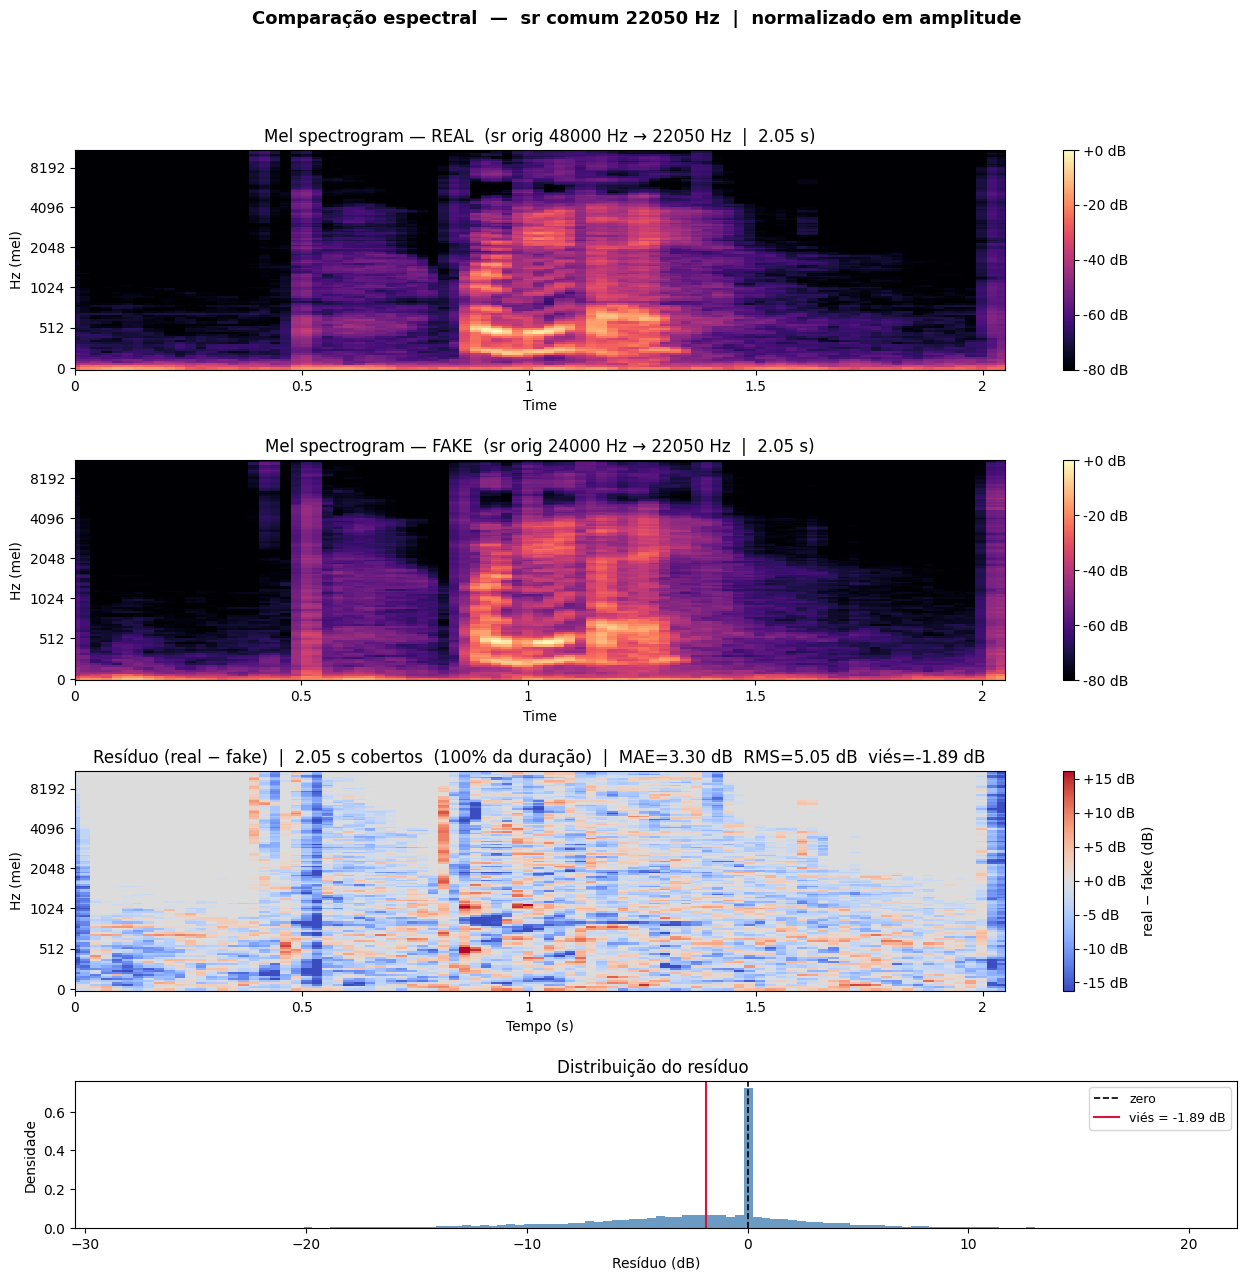

In [97]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── parâmetros ────────────────────────────────────────────────────────────────
hop_length = 512
n_fft      = 2048
n_mels     = 128
SR_TARGET  = 22050          # sr comum para comparação justa

# ── carregamento e reamostagem para sr comum ──────────────────────────────────
y_real_orig, sr_real_orig = librosa.load(real, sr=None, mono=True)
y_fake_orig, sr_fake_orig = librosa.load(fake, sr=None, mono=True)

dur_real_orig = len(y_real_orig) / sr_real_orig
dur_fake_orig = len(y_fake_orig) / sr_fake_orig

# reamostrar para sr comum (necessário para resíduo correto)
y_real = librosa.resample(y_real_orig, orig_sr=sr_real_orig, target_sr=SR_TARGET) \
         if sr_real_orig != SR_TARGET else y_real_orig
y_fake = librosa.resample(y_fake_orig, orig_sr=sr_fake_orig, target_sr=SR_TARGET) \
         if sr_fake_orig != SR_TARGET else y_fake_orig

# ── normalização de amplitude (isola diferenças espectrais de ganho) ──────────
y_real = y_real / (np.max(np.abs(y_real)) + 1e-9)
y_fake = y_fake / (np.max(np.abs(y_fake)) + 1e-9)

dur_real = len(y_real) / SR_TARGET
dur_fake = len(y_fake) / SR_TARGET

# ── mel spectrogramas no sr comum ─────────────────────────────────────────────
M_real = librosa.power_to_db(
    librosa.feature.melspectrogram(
        y=y_real, sr=SR_TARGET, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
    ),
    ref=np.max
)
M_fake = librosa.power_to_db(
    librosa.feature.melspectrogram(
        y=y_fake, sr=SR_TARGET, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
    ),
    ref=np.max
)

# ── alinhamento temporal e resíduo ────────────────────────────────────────────
min_frames = min(M_real.shape[1], M_fake.shape[1])
M_real_al  = M_real[:, :min_frames]
M_fake_al  = M_fake[:, :min_frames]
M_residuo  = M_real_al - M_fake_al
dur_res    = min(dur_real, dur_fake)

frac_covered = dur_res / max(dur_real, dur_fake)
print(f"Cobertura da comparação: {frac_covered*100:.1f}% da duração total")

# ── métricas ──────────────────────────────────────────────────────────────────
mae = np.mean(np.abs(M_residuo))
rms = np.sqrt(np.mean(M_residuo**2))
max_err = np.max(np.abs(M_residuo))
bias = np.mean(M_residuo)           # novo: viés sistemático (real > fake se +)

print(f"\nsr real (original) : {sr_real_orig} Hz  |  duração: {dur_real_orig:.3f} s")
print(f"sr fake (original) : {sr_fake_orig} Hz  |  duração: {dur_fake_orig:.3f} s")
print(f"sr comum usado      : {SR_TARGET} Hz")
print(f"\nMAE espectral  : {mae:.4f} dB")
print(f"RMS espectral  : {rms:.4f} dB")
print(f"Max espectral  : {max_err:.4f} dB")
print(f"Viés médio     : {bias:+.4f} dB  {'(real mais energético)' if bias>0 else '(fake mais energético)'}")

# ── visualização ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 14))
fig.suptitle(
    f"Comparação espectral  —  sr comum {SR_TARGET} Hz  |  normalizado em amplitude",
    fontsize=13, fontweight="bold"
)

gs = gridspec.GridSpec(4, 1, figure=fig, height_ratios=[3, 3, 3, 2], hspace=0.45)

ax_real = fig.add_subplot(gs[0])
ax_fake = fig.add_subplot(gs[1])
ax_res  = fig.add_subplot(gs[2])
ax_hist = fig.add_subplot(gs[3])

# ── painel 1: real ────────────────────────────────────────────────────────────
img1 = librosa.display.specshow(
    M_real, sr=SR_TARGET, hop_length=hop_length,
    x_axis="time", y_axis="mel", ax=ax_real, cmap="magma"
)
ax_real.set_title(
    f"Mel spectrogram — REAL  "
    f"(sr orig {sr_real_orig} Hz → {SR_TARGET} Hz  |  {dur_real_orig:.2f} s)"
)
ax_real.set_ylabel("Hz (mel)")
ax_real.set_xlim(0, dur_real)
fig.colorbar(img1, ax=ax_real, format="%+2.0f dB")

# ── painel 2: fake ────────────────────────────────────────────────────────────
img2 = librosa.display.specshow(
    M_fake, sr=SR_TARGET, hop_length=hop_length,
    x_axis="time", y_axis="mel", ax=ax_fake, cmap="magma"
)
ax_fake.set_title(
    f"Mel spectrogram — FAKE  "
    f"(sr orig {sr_fake_orig} Hz → {SR_TARGET} Hz  |  {dur_fake_orig:.2f} s)"
)
ax_fake.set_ylabel("Hz (mel)")
ax_fake.set_xlim(0, dur_fake)
fig.colorbar(img2, ax=ax_fake, format="%+2.0f dB")

# ── painel 3: resíduo ─────────────────────────────────────────────────────────
vmax = np.percentile(np.abs(M_residuo), 99)   # escala robusta (ignora outliers)
img3 = librosa.display.specshow(
    M_residuo, sr=SR_TARGET, hop_length=hop_length,
    x_axis="time", y_axis="mel", ax=ax_res,
    cmap="coolwarm", vmin=-vmax, vmax=vmax      # simétrico em torno de 0
)
ax_res.set_title(
    f"Resíduo (real − fake)  |  {dur_res:.2f} s cobertos  "
    f"({frac_covered*100:.0f}% da duração)  |  "
    f"MAE={mae:.2f} dB  RMS={rms:.2f} dB  viés={bias:+.2f} dB"
)
ax_res.set_ylabel("Hz (mel)")
ax_res.set_xlabel("Tempo (s)")
ax_res.set_xlim(0, dur_res)
cb3 = fig.colorbar(img3, ax=ax_res, format="%+2.0f dB")
cb3.set_label("real − fake (dB)")

# ── painel 4: histograma do resíduo ──────────────────────────────────────────
residuo_flat = M_residuo.ravel()
ax_hist.hist(residuo_flat, bins=120, color="steelblue", alpha=0.8, density=True)
ax_hist.axvline(0,    color="black",  lw=1.2, linestyle="--", label="zero")
ax_hist.axvline(bias, color="crimson", lw=1.5, linestyle="-",  label=f"viés = {bias:+.2f} dB")
ax_hist.set_xlabel("Resíduo (dB)")
ax_hist.set_ylabel("Densidade")
ax_hist.set_title("Distribuição do resíduo ")
ax_hist.legend(fontsize=9)

plt.tight_layout()
plt.show()